# M-competition — a *sharp* ranking of forecasting methods (Step 4)

The final point on the arc **macro (null) → GJP (partial) → M-competition (sharp)**.
Ranking standard forecasting methods over the thousands of M3 series, the *same*
rank-CI pipeline delivers a decisive ordering: the top methods are pinned to exact
ranks.

**Why so sharp.** Two forces: (i) huge n (1,428 monthly series) shrinks the standard
errors; (ii) the methods are highly **correlated across series** — a hard series hurts
everyone — so each series' difficulty is a shared shock that **cancels in the sMAPE
differences**, making the paired differences far less variable than the marginals. The
method separates methods that look tied on their marginal averages.

**Structure** = same as GJP/macro: rows = series (the observation axis; unordered, so
serial dependence ~ 0 and this isolates the cross-sectional / common-shock side),
columns = methods, one sMAPE per (series, method). Data: M3 (Makridakis et al.),
auto-downloaded via `datasetsforecast`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from rankci.data.mcomp import method_panel
from rankci import (rank_ci_stepwise_pairwise,
                    rank_ci_stepwise_simulation_pairwise,
                    rank_ci_marginal_pairwise)
ALPHA = 0.10
METHODS = ["naive2", "snaive", "ets", "damped", "theta"]   # +comb added inside
pd.set_option("display.width", 170)

Matplotlib is building the font cache; this may take a moment.


## 1. Build the (series x method) sMAPE panel — M3 Monthly (1,428 series)

Each series: fit on all but the last 18 points, forecast 18 ahead, score with sMAPE.
Benchmarks (Naive2, Seasonal-Naive) and serious methods (ETS, Damped-ETS, Theta) plus
their combination. (First run downloads M3 and builds the panel ~150s, then caches it.)

In [2]:
panel = method_panel(group="Monthly", methods=METHODS, metric="smape",
                     cache=True, include_comb=True)
X = panel.values
methods = list(panel.columns)
p = X.shape[1]
theta = X.mean(axis=0)
print(f"panel: {X.shape[0]} series x {p} methods")
print("mean sMAPE:", {m: round(float(t), 2) for m, t in zip(methods, theta)})

100%|██████████| 336k/336k [00:00<00:00, 2.96MiB/s]
INFO:datasetsforecast.utils:Successfully downloaded m3_monthly_dataset.zip, 336324, bytes.
INFO:datasetsforecast.utils:Decompressing zip file...
INFO:datasetsforecast.utils:Successfully decompressed data/mcomp/m3/datasets/m3_monthly_dataset.zip
/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/Parimah/Desktop/ranks-inference-forecasters/.

panel: 1428 series x 6 methods
mean sMAPE: {'naive2': 16.81, 'snaive': 17.24, 'ets': 17.46, 'damped': 15.84, 'theta': 13.97, 'comb': 14.99}


## 2. The ranking — rank confidence intervals

In [3]:
boot = rank_ci_stepwise_pairwise(X, alpha=ALPHA, B=1000, seed=42, verbose=False)
mds  = rank_ci_stepwise_simulation_pairwise(X, alpha=ALPHA, B=4000, seed=42, covariance="mds",   verbose=False)
om   = rank_ci_stepwise_simulation_pairwise(X, alpha=ALPHA, B=4000, seed=42, covariance="omega", verbose=False)
marg = rank_ci_marginal_pairwise(X, alpha=ALPHA, B=1000, seed=42)

tab = pd.DataFrame({
    "method":  methods,
    "mean_sMAPE": theta.round(2),
    "CI_boot":  [f"[{l},{u}]" for l, u in boot["rank_ci"]],
    "CI_mds":   [f"[{l},{u}]" for l, u in mds["rank_ci"]],
    "CI_omega": [f"[{l},{u}]" for l, u in om["rank_ci"]],
    "CI_marg":  [f"[{l},{u}]" for l, u in marg["rank_ci"]],
}).sort_values("mean_sMAPE").reset_index(drop=True)
tab.index += 1; tab.index.name = "point rank"
tab

,method,mean_sMAPE,CI_boot,CI_mds,CI_omega,CI_marg
point rank,,,,,,
1,theta,13.97,"[1,1]","[1,1]","[1,1]","[1,1]"
2,comb,14.99,"[2,2]","[2,2]","[2,2]","[2,2]"
3,damped,15.84,"[3,3]","[3,3]","[3,3]","[3,3]"
4,naive2,16.81,"[4,6]","[4,6]","[4,6]","[4,6]"
5,snaive,17.24,"[4,6]","[4,6]","[4,6]","[4,6]"
6,ets,17.46,"[4,6]","[4,6]","[4,6]","[4,6]"


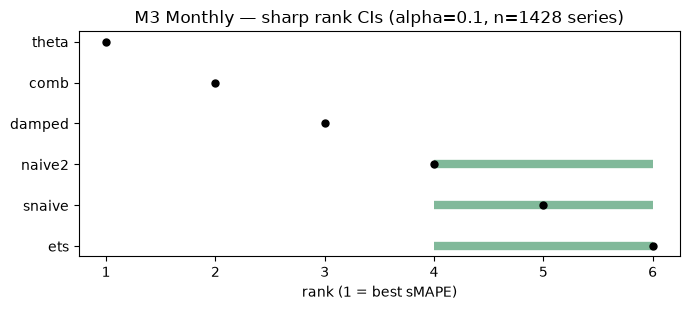

In [4]:
order = np.argsort(theta); ci = om["rank_ci"][order]; yy = np.arange(p)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hlines(yy, ci[:, 0], ci[:, 1], color="seagreen", lw=6, alpha=0.6)
ax.plot(np.arange(1, p + 1), yy, "o", color="black", ms=5)
ax.set_yticks(yy); ax.set_yticklabels([methods[i] for i in order]); ax.invert_yaxis()
ax.set_xlabel("rank (1 = best sMAPE)"); ax.set_xticks(range(1, p + 1))
ax.set_title(f"M3 Monthly — sharp rank CIs (alpha={ALPHA}, n={X.shape[0]} series)")
fig.tight_layout(); plt.show()

## 3. Robustness across frequencies

Theta > Comb > Damped is stable across Monthly / Quarterly / Yearly; sharpness scales
with the number of series.

In [5]:
rows = []
for g in ["Monthly", "Quarterly", "Yearly"]:
    pn = method_panel(group=g, methods=METHODS, cache=True, include_comb=True)
    th = pn.values.mean(axis=0); od = np.argsort(th)
    o = rank_ci_stepwise_simulation_pairwise(pn.values, alpha=ALPHA, B=3000, seed=42,
                                             covariance="omega", verbose=False)
    w = (o["rank_ci"][:, 1] - o["rank_ci"][:, 0]).mean()
    rows.append({"group": g, "n_series": pn.shape[0],
                 "order (best->worst)": " > ".join(pn.columns[j] for j in od),
                 "mean_CI_width": round(float(w), 2)})
pd.DataFrame(rows).set_index("group")

100%|██████████| 96.1k/96.1k [00:00<00:00, 1.35MiB/s]
INFO:datasetsforecast.utils:Successfully downloaded m3_quarterly_dataset.zip, 96124, bytes.
INFO:datasetsforecast.utils:Decompressing zip file...
INFO:datasetsforecast.utils:Successfully decompressed data/mcomp/m3/datasets/m3_quarterly_dataset.zip
100%|██████████| 50.2k/50.2k [00:00<00:00, 742kiB/s]
INFO:datasetsforecast.utils:Successfully downloaded m3_yearly_dataset.zip, 50178, bytes.
INFO:datasetsforecast.utils:Decompressing zip file...
INFO:datasetsforecast.utils:Successfully decompressed data/mcomp/m3/datasets/m3_yearly_dataset.zip
/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check

,n_series,order (best->worst),mean_CI_width
group,,,
Monthly,1428,theta > comb > damped > naive2 > snaive > ets,1.00
Quarterly,756,theta > comb > damped > naive2 > ets > snaive,1.67
Yearly,645,theta > comb > damped > naive2 > snaive > ets,3.00


## 4. The three regimes — one method, one figure

Same `rankci` pipeline on three panels. Normalised CI width (mean width / (p-1)) and
the fraction of methods/forecasters pinned to an exact rank make the contrast explicit.

In [6]:
from rankci import select_top_forecasters
from rankci.data.philly import load_spf, load_rtdsm, compute_error_panel
from rankci.data.gjp import load_gjp_ifps, load_gjp_forecasts, brier_panel

# macro (NGDP, top 8)
spf = load_spf("../../data/philly/SPFmicrodata.xlsx", sheet="NGDP")
rt  = load_rtdsm("../../data/philly/NOUTPUTQvQd.xlsx", prefix="NOUTPUT")
Xmac = select_top_forecasters(compute_error_panel(spf, rt, "NGDP", 3, "squared"), N=8, min_obs=20).values
# GJP (top 20, yr1+2)
ifps = load_gjp_ifps("../../data/gjp/ifps.csv")
gfc  = load_gjp_forecasts(["../../data/gjp/survey_fcasts.yr1.csv", "../../data/gjp/survey_fcasts.yr2.csv"])
Xgjp, _ = brier_panel(gfc, ifps, condition="individual", min_questions=60, top_n=20, years=[1, 2])
Xgjp = Xgjp.values
# M-comp (Monthly)
Xmc = X

def summarise(name, Xp):
    o = rank_ci_stepwise_simulation_pairwise(Xp, alpha=ALPHA, B=3000, seed=42,
                                             covariance="omega", verbose=False)
    ci = o["rank_ci"]; pp = Xp.shape[1]
    return {"dataset": name, "p": pp, "n_obs": Xp.shape[0],
            "norm_width": round(float((ci[:, 1] - ci[:, 0]).mean() / (pp - 1)), 2),
            "frac_separated": round(float(((ci[:, 0] > 1) | (ci[:, 1] < pp)).mean()), 2),
            "n_exact_ranks": int((ci[:, 0] == ci[:, 1]).sum())}

pd.DataFrame([summarise("macro (NGDP)", Xmac),
              summarise("GJP (geopolitical)", Xgjp),
              summarise("M-comp (Monthly)", Xmc)]).set_index("dataset")

,p,n_obs,norm_width,frac_separated,n_exact_ranks
dataset,,,,,
macro (NGDP),8,225,1.00,0.0,0
GJP (geopolitical),20,212,0.73,1.0,1
M-comp (Monthly),6,1428,0.20,1.0,3


## Summary

- **Sharp and non-obvious.** On 1,428 monthly M3 series the ranking is decisive:
  **Theta** is confidently best (rank `[1,1]`, recovering the famous M3 result), the
  **combination** second, **Damped-ETS** third; the three simple benchmarks form a tie
  group. Mean rank-CI width ~1 of 5. Stable across frequencies.
- **The method's core value on display.** Theta and the combination differ by ~1 sMAPE
  point on the marginals, yet are separated with confidence — because the paired
  differences (after the shared per-series difficulty cancels) have far smaller
  variance. This is exactly what difference-based rank inference buys.
- **One method, three regimes.** The identical covariance-estimation pipeline feeding
  MRSW reports: macro forecasters *indistinguishable* (`[1,p]`), GJP forecasters
  *partially* separable (top tier only), M-competition methods *sharply* ordered. The
  width of the confidence set is an honest read of how much the data can support.